In [ ]:


# 1. Check GPU

import torch

print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: GPU not detected. In Colab go to Runtime > Change runtime type > GPU")


Torch: 2.10.0+cu128
CUDA: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition


In [ ]:


# 2. Install dependencies

!pip -q install kagglehub
!pip -q install timm
!pip -q install albumentations
!pip -q install opencv-python
!pip -q install tqdm


In [ ]:

# 3. Download dataset

import kagglehub
import os

path = kagglehub.dataset_download("debeshjha1/polypdb")
print("Dataset path:", path)

# Inspect structure (first level)
for root, dirs, files in os.walk(path):
    print(root, "files:", len(files), "dirs:", len(dirs))
    break


100%|██████████| 1.29G/1.29G [00:34<00:00, 39.8MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/debeshjha1/polypdb/versions/1
/root/.cache/kagglehub/datasets/debeshjha1/polypdb/versions/1 files: 0 dirs: 1


In [ ]:

# DEBUG DATASET STRUCTURE

import os

for root, dirs, files in os.walk(path):
    print(root)
    print("dirs:", dirs)
    print("files sample:", files[:5])
    print("------")
    break

/root/.cache/kagglehub/datasets/debeshjha1/polypdb/versions/1
dirs: ['PolypDB']
files sample: []
------


In [ ]:

for root, dirs, files in os.walk(path):
    if len(files) > 0:
        print(root)
        print("sample files:", files[:3])
        print("------")

/root/.cache/kagglehub/datasets/debeshjha1/polypdb/versions/1/PolypDB/PolypDB/PolypDB_modality_wise/BLI/masks
sample files: ['PKHL_15 220831_201102_BN054_034.png', 'PKHL_15 220831_201028_BN026_017.png', 'PKHL_15 220831_201028_BN054_036.png']
------
/root/.cache/kagglehub/datasets/debeshjha1/polypdb/versions/1/PolypDB/PolypDB/PolypDB_modality_wise/BLI/images
sample files: ['PKHL_15 220831_201028_BN054_034.jpg', 'PKHL_15 220831_201029_BN041_022.jpg', 'PKHL_15 220831_201030_BN057_037.jpg']
------
/root/.cache/kagglehub/datasets/debeshjha1/polypdb/versions/1/PolypDB/PolypDB/PolypDB_modality_wise/WLI/masks
sample files: ['fbec422b-75c5-4f94-ae77-18334055a3c8.png', 'HMUH_06 200731_200728_BN079_005.png', 'HMUH_08 200822_200820_BN067_001.png']
------
/root/.cache/kagglehub/datasets/debeshjha1/polypdb/versions/1/PolypDB/PolypDB/PolypDB_modality_wise/WLI/images
sample files: ['0e4c86e0-b0e4-4a52-98a0-6fc80cf2ebe9.jpg', 'HMUH_06 200731_200716_BN002_002.jpg', 'HMUH_06 200731_200723_BN058_005.jpg']

##debug


In [ ]:

# DEBUG B. Show structure with sample files

import os

max_depth = 5
base_depth = path.count(os.sep)

for root, dirs, files in os.walk(path):
    depth = root.count(os.sep) - base_depth
    if depth <= max_depth:
        indent = "  " * depth
        print(f"{indent}{os.path.basename(root)}/")
        if files:
            sample = files[:3]
            print(f"{indent}  sample files: {sample}")

polypdb/
  PolypDB/
    PolypDB/
      PolypDB_center_wise/
        Simula/
          NBI/
          WLI/
        BKAI/
          FICE/
          BLI/
          WLI/
          LCI/
        Karolinska/
          WLI/
      PolypDB_modality_wise/
        FICE/
          images/
            sample files: ['HMUH_16 201207_201128_BN001_001.jpg', 'HMUH_16 201207_201126_BN007_002.jpg', 'HMUH_15 201129_201112_BN001_001.jpg']
          masks/
            sample files: ['HMUH_15 201129_201123_BN002_003.png', 'HMUH_15 201129_201119_BN005_002.png', 'HMUH_16 201207_201120_BN001_002.png']
        BLI/
          images/
            sample files: ['PKHL_15 220831_201030_BN011_036.jpg', 'PKHL_15 220831_201028_BN026_014.jpg', 'PKHL_15 220831_201028_BN028_023.jpg']
          masks/
            sample files: ['PKHL_15 220831_201031_BN073_052.jpg', 'PKHL_15 220831_201030_BN006_028.png', 'PKHL_15 220831_201030_BN025_004.png']
        NBI/
          images/
            sample files: ['76144e5b-6e52-493f-825e

##fin debug

In [ ]:

# 4. Prepare matched image-mask pairs from PolypDB_modality_wise

import glob
import os

modality_root = os.path.join(path, "PolypDB", "PolypDB", "PolypDB_modality_wise")
print("Using modality root:", modality_root)

modalities = ["FICE", "BLI", "NBI", "WLI", "LCI"]
valid_ext = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

images = []
masks = []

for mod in modalities:
    img_dir = os.path.join(modality_root, mod, "images")
    msk_dir = os.path.join(modality_root, mod, "masks")

    img_files = sorted([
        p for p in glob.glob(os.path.join(img_dir, "*.*"))
        if os.path.splitext(p)[1].lower() in valid_ext
    ])
    msk_files = sorted([
        p for p in glob.glob(os.path.join(msk_dir, "*.*"))
        if os.path.splitext(p)[1].lower() in valid_ext
    ])

    print(f"\nModality: {mod}")
    print("  images found:", len(img_files))
    print("  masks found :", len(msk_files))

    # Match by filename stem, not full filename
    img_dict = {os.path.splitext(os.path.basename(p))[0]: p for p in img_files}
    msk_dict = {os.path.splitext(os.path.basename(p))[0]: p for p in msk_files}

    common_keys = sorted(set(img_dict.keys()) & set(msk_dict.keys()))

    print("  matched pairs:", len(common_keys))
    if common_keys:
        print("  sample key:", common_keys[0])

    images.extend([img_dict[k] for k in common_keys])
    masks.extend([msk_dict[k] for k in common_keys])

print("\nTOTAL MATCHED PAIRS:", len(images))
assert len(images) > 0, "No matched pairs found"
assert len(images) == len(masks), "Image/mask count mismatch after matching"

print("Sample image:", images[0])
print("Sample mask :", masks[0])

# Split
split = int(0.8 * len(images))
train_imgs, val_imgs = images[:split], images[split:]
train_masks, val_masks = masks[:split], masks[split:]

print("Train:", len(train_imgs), "Val:", len(val_imgs))

Using modality root: /kaggle/input/polypdb/PolypDB/PolypDB/PolypDB_modality_wise

Modality: FICE
  images found: 70
  masks found : 70
  matched pairs: 70
  sample key: HMUH_15 201129_201111_BN001_001

Modality: BLI
  images found: 70
  masks found : 70
  matched pairs: 70
  sample key: PKHL_15 220831_201026_BN032_027

Modality: NBI
  images found: 146
  masks found : 146
  matched pairs: 146
  sample key: 010f72b7-a411-4974-b862-9dacdb6cb6fb

Modality: WLI
  images found: 3588
  masks found : 3588
  matched pairs: 3588
  sample key: 00220261-67c0-41e4-b728-84381341846c

Modality: LCI
  images found: 60
  masks found : 60
  matched pairs: 60
  sample key: PKHL_15 220831_201209_BN004_045

TOTAL MATCHED PAIRS: 3934
Sample image: /kaggle/input/polypdb/PolypDB/PolypDB/PolypDB_modality_wise/FICE/images/HMUH_15 201129_201111_BN001_001.jpg
Sample mask : /kaggle/input/polypdb/PolypDB/PolypDB/PolypDB_modality_wise/FICE/masks/HMUH_15 201129_201111_BN001_001.png
Train: 3147 Val: 787


In [ ]:


# 5. Dataset class

import cv2
import numpy as np
import torch
from torch.utils.data import Dataset

class PolypDataset(Dataset):
    def __init__(self, imgs, masks, size=352, transform=None):
        self.imgs = imgs
        self.masks = masks
        self.size = size
        self.transform = transform

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img = cv2.imread(self.imgs[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(self.masks[idx], 0)

        img = cv2.resize(img, (self.size, self.size))
        mask = cv2.resize(mask, (self.size, self.size))

        # 🔥 AQUI VA EL AUGMENTATION
        if self.transform:
            aug = self.transform(image=img, mask=mask)
            img = aug["image"]
            mask = aug["mask"]

        img = img / 255.0
        mask = (mask > 0).astype(np.float32)

        img = np.transpose(img, (2,0,1))

        return {
            "image": torch.tensor(img, dtype=torch.float32),
            "mask": torch.tensor(mask, dtype=torch.float32).unsqueeze(0)
        }

In [ ]:

# 5A. Augmentations

import albumentations as A

transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=30, p=0.5),
])

In [ ]:

# 6. DataLoader

from torch.utils.data import DataLoader

train_ds = PolypDataset(train_imgs, train_masks, transform=transform)
val_ds   = PolypDataset(val_imgs, val_masks, transform=None)

print("Train dataset size:", len(train_ds))
print("Val dataset size  :", len(val_ds))

assert len(train_ds) > 0, "Empty training dataset"
assert len(val_ds) > 0, "Empty validation dataset"

# Use num_workers=0 for easier debugging in Colab/Kaggle
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=0, pin_memory=True)

print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))


Train dataset size: 3147
Val dataset size  : 787
Train batches: 394
Val batches  : 99


In [ ]:

# 7. Polyp-PVT real-like model (fixed dynamic channels)

import torch
import torch.nn as nn
import torch.nn.functional as F
import timm


class BasicConv2d(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, stride=1, padding=0, dilation=1):
        super().__init__()
        self.conv = nn.Conv2d(
            in_ch, out_ch,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding,
            dilation=dilation,
            bias=False
        )
        self.bn = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.bn(self.conv(x)))


class Reduction(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = BasicConv2d(in_ch, out_ch, kernel_size=1)

    def forward(self, x):
        return self.block(x)


class CFM(nn.Module):
    def __init__(self, channel=32):
        super().__init__()
        self.conv_upsample1 = BasicConv2d(channel, channel, 3, padding=1)
        self.conv_upsample2 = BasicConv2d(channel, channel, 3, padding=1)
        self.conv_upsample3 = BasicConv2d(channel, channel, 3, padding=1)

        self.conv_concat2 = BasicConv2d(channel * 2, channel * 2, 3, padding=1)

        # FIX: input here is 64 + 32 + 32 = 128 = channel * 4
        self.conv_concat3 = BasicConv2d(channel * 4, channel * 4, 3, padding=1)

        # FIX: output of conv_concat3 is also channel * 4
        self.conv_out = BasicConv2d(channel * 4, channel, 3, padding=1)

    def forward(self, x4, x3, x2):
        x4_up = F.interpolate(
            self.conv_upsample1(x4),
            size=x3.shape[2:],
            mode="bilinear",
            align_corners=False
        )
        x3_f = x4_up * x3

        x3_up = F.interpolate(
            self.conv_upsample2(x3_f),
            size=x2.shape[2:],
            mode="bilinear",
            align_corners=False
        )
        x4_up2 = F.interpolate(
            self.conv_upsample3(x4),
            size=x2.shape[2:],
            mode="bilinear",
            align_corners=False
        )
        x2_f = x3_up * x2 * x4_up2

        x3_cat = torch.cat([
            F.interpolate(x4, size=x3.shape[2:], mode="bilinear", align_corners=False),
            x3_f
        ], dim=1)
        x3_cat = self.conv_concat2(x3_cat)

        x2_cat = torch.cat([
            F.interpolate(x3_cat, size=x2.shape[2:], mode="bilinear", align_corners=False),
            x2_f,
            x2
        ], dim=1)
        x2_cat = self.conv_concat3(x2_cat)

        out = self.conv_out(x2_cat)
        return out


class CIM(nn.Module):
    def __init__(self, low_ch, channel=32):
        super().__init__()
        self.low_proj = BasicConv2d(low_ch, channel, 1)
        self.fuse = nn.Sequential(
            BasicConv2d(channel * 2, channel, 3, padding=1),
            BasicConv2d(channel, channel, 3, padding=1),
        )

    def forward(self, low_feat, high_feat):
        low_feat = self.low_proj(low_feat)
        high_up = F.interpolate(high_feat, size=low_feat.shape[2:], mode="bilinear", align_corners=False)
        x = torch.cat([low_feat, high_up], dim=1)
        return self.fuse(x)


class SAM(nn.Module):
    def __init__(self, channel=32):
        super().__init__()
        self.conv1 = BasicConv2d(channel + 1, channel, 3, padding=1)
        self.conv2 = BasicConv2d(channel, channel, 3, padding=1)
        self.out = nn.Conv2d(channel, channel, 1)

    def forward(self, feat, coarse_pred):
        coarse_prob = torch.sigmoid(coarse_pred)
        coarse_prob = F.interpolate(coarse_prob, size=feat.shape[2:], mode="bilinear", align_corners=False)

        x = torch.cat([feat, coarse_prob], dim=1)
        x = self.conv1(x)
        x = self.conv2(x)

        att = torch.sigmoid(self.out(x))
        refined = feat * att + feat
        return refined


class PredHead(nn.Module):
    def __init__(self, in_ch):
        super().__init__()
        self.head = nn.Conv2d(in_ch, 1, kernel_size=1)

    def forward(self, x, out_size):
        x = self.head(x)
        x = F.interpolate(x, size=out_size, mode="bilinear", align_corners=False)
        return x


class PolypPVT_RealLike(nn.Module):
    def __init__(self, channel=32, backbone_name="pvt_v2_b2"):
        super().__init__()

        self.backbone = timm.create_model(
            backbone_name,
            pretrained=True,
            features_only=True,
            out_indices=(0, 1, 2, 3)
        )

        feat_channels = self.backbone.feature_info.channels()
        print("Backbone feature channels:", feat_channels)

        c1, c2, c3, c4 = feat_channels

        self.reduce_x2 = Reduction(c2, channel)
        self.reduce_x3 = Reduction(c3, channel)
        self.reduce_x4 = Reduction(c4, channel)

        self.cfm = CFM(channel=channel)
        self.cim = CIM(low_ch=c1, channel=channel)
        self.sam = SAM(channel=channel)

        self.pred_coarse = PredHead(channel)
        self.pred_final = PredHead(channel)

    def forward(self, x):
        out_size = x.shape[2:]

        feats = self.backbone(x)
        x1, x2, x3, x4 = feats

        x2_r = self.reduce_x2(x2)
        x3_r = self.reduce_x3(x3)
        x4_r = self.reduce_x4(x4)

        cfm_feat = self.cfm(x4_r, x3_r, x2_r)
        cim_feat = self.cim(x1, cfm_feat)

        pred1 = self.pred_coarse(cfm_feat, out_size)
        sam_feat = self.sam(cim_feat, pred1)
        pred2 = self.pred_final(sam_feat, out_size)

        return pred1, pred2


device = "cuda" if torch.cuda.is_available() else "cpu"
model = PolypPVT_RealLike(channel=32).to(device)

print("Device:", device)
print("Model loaded:", model.__class__.__name__)

# Quick shape sanity check
batch = next(iter(train_loader))
x = batch["image"].to(device)

with torch.no_grad():
    p1, p2 = model(x[:2])

print("Input shape :", x[:2].shape)
print("Pred1 shape :", p1.shape)
print("Pred2 shape :", p2.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/101M [00:00<?, ?B/s]

Backbone feature channels: [64, 128, 320, 512]
Device: cuda
Model loaded: PolypPVT_RealLike
Input shape : torch.Size([2, 3, 352, 352])
Pred1 shape : torch.Size([2, 1, 352, 352])
Pred2 shape : torch.Size([2, 1, 352, 352])


In [ ]:

# 8. Loss & metrics

import torch
import torch.nn.functional as F

def bce_dice_loss(pred, target):
    bce = F.binary_cross_entropy_with_logits(pred, target)

    pred = torch.sigmoid(pred)
    smooth = 1e-6
    intersection = (pred * target).sum(dim=(1, 2, 3))
    dice = 1 - (2.0 * intersection + smooth) / (pred.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3)) + smooth)

    return bce + dice.mean()

def compute_dice(pred, target, eps=1e-6):
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum(dim=(1, 2, 3))
    dice = (2.0 * intersection + eps) / (pred.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3)) + eps)
    return dice.mean()


In [ ]:

# 9. Training loop

import os
import json
import pandas as pd
from tqdm import tqdm

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=8
)

history = []
best_dice = -1.0
EPOCHS = 100

for ep in range(EPOCHS):
    model.train()
    total_loss = 0.0

    for batch in tqdm(train_loader, desc=f"Train {ep+1}/{EPOCHS}"):
        imgs = batch["image"].to(device, non_blocking=True)
        masks = batch["mask"].to(device, non_blocking=True)

        pred1, pred2 = model(imgs)

        loss1 = bce_dice_loss(pred1, masks)
        loss2 = bce_dice_loss(pred2, masks)
        loss = 0.4 * loss1 + 1.0 * loss2

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    train_loss = total_loss / max(len(train_loader), 1)

    model.eval()
    dice_scores = []

    with torch.no_grad():
        for batch in val_loader:
            imgs = batch["image"].to(device, non_blocking=True)
            masks = batch["mask"].to(device, non_blocking=True)

            _, pred2 = model(imgs)
            pred2 = torch.sigmoid(pred2)

            dice = compute_dice(pred2, masks)
            dice_scores.append(dice.item())

    val_dice = sum(dice_scores) / max(len(dice_scores), 1)
    current_lr = optimizer.param_groups[0]["lr"]
    scheduler.step(val_dice)

    print(f"Epoch {ep+1:03d} | train_loss={train_loss:.6f} | val_dice={val_dice:.6f} | lr={current_lr:.2e}")

    history.append({
        "epoch": ep + 1,
        "loss": train_loss,
        "val_dice": val_dice,
        "lr": current_lr
    })

    torch.save(model.state_dict(), "polyp_pvt_real_like_last.pt")

    if val_dice > best_dice:
        best_dice = val_dice
        torch.save(model.state_dict(), "polyp_pvt_real_like_best.pt")
        print(f"Saved new best model at epoch {ep+1} with val_dice={val_dice:.6f}")

with open("training_history.json", "w") as f:
    json.dump(history, f, indent=2)

print("Best validation Dice:", best_dice)


Train 1/100: 100%|██████████| 394/394 [01:40<00:00,  3.91it/s]


Epoch 001 | train_loss=1.812290 | val_dice=0.777717 | lr=1.00e-04
Saved new best model at epoch 1 with val_dice=0.777717


Train 2/100: 100%|██████████| 394/394 [01:00<00:00,  6.52it/s]


Epoch 002 | train_loss=1.276495 | val_dice=0.824219 | lr=1.00e-04
Saved new best model at epoch 2 with val_dice=0.824219


Train 3/100: 100%|██████████| 394/394 [00:59<00:00,  6.58it/s]


...

Epoch 098 | train_loss=0.100507 | val_dice=0.922956 | lr=1.56e-06


Train 99/100: 100%|██████████| 394/394 [01:00<00:00,  6.51it/s]


Epoch 099 | train_loss=0.100677 | val_dice=0.922770 | lr=1.56e-06


Train 100/100: 100%|██████████| 394/394 [01:00<00:00,  6.53it/s]


Epoch 100 | train_loss=0.100740 | val_dice=0.922975 | lr=1.56e-06
Best validation Dice: 0.9252032246252503


In [ ]:

# 10. Find best threshold on final
import json
import numpy as np
import torch

model.eval()

best_thr = 0.5
best_thr_dice = -1.0

for t in np.arange(0.30, 0.71, 0.05):
    dice_scores = []

    with torch.no_grad():
        for batch in val_loader:
            imgs = batch["image"].to(device, non_blocking=True)
            masks = batch["mask"].to(device, non_blocking=True)

            _, pred2 = model(imgs)
            preds = torch.sigmoid(pred2)
            preds_bin = (preds > t).float()

            dice = compute_dice(preds_bin, masks)
            dice_scores.append(dice.item())

    avg = sum(dice_scores) / max(len(dice_scores), 1)
    print(f"Threshold {t:.2f} -> Dice {avg:.6f}")

    if avg > best_thr_dice:
        best_thr_dice = avg
        best_thr = float(t)

threshold_info = {
    "best_threshold": best_thr,
    "best_threshold_dice": best_thr_dice
}

with open("best_threshold.json", "w") as f:
    json.dump(threshold_info, f, indent=2)

print("\nBEST THRESHOLD:", best_thr)
print("BEST DICE AT THRESHOLD:", best_thr_dice)


Threshold 0.30 -> Dice 0.922999
Threshold 0.35 -> Dice 0.923134
Threshold 0.40 -> Dice 0.923165
Threshold 0.45 -> Dice 0.923086
Threshold 0.50 -> Dice 0.922975
Threshold 0.55 -> Dice 0.922811
Threshold 0.60 -> Dice 0.922577
Threshold 0.65 -> Dice 0.922254
Threshold 0.70 -> Dice 0.921830

BEST THRESHOLD: 0.39999999999999997
BEST DICE AT THRESHOLD: 0.9231654965516293


In [ ]:
# 10B. Save metrics

import pandas as pd

df = pd.DataFrame(history)
df.to_csv("metrics.csv", index=False)

print(df.tail())


    epoch      loss  val_dice        lr
95     96  0.100686  0.922881  0.000002
96     97  0.100690  0.923014  0.000002
97     98  0.100507  0.922956  0.000002
98     99  0.100677  0.922770  0.000002
99    100  0.100740  0.922975  0.000002


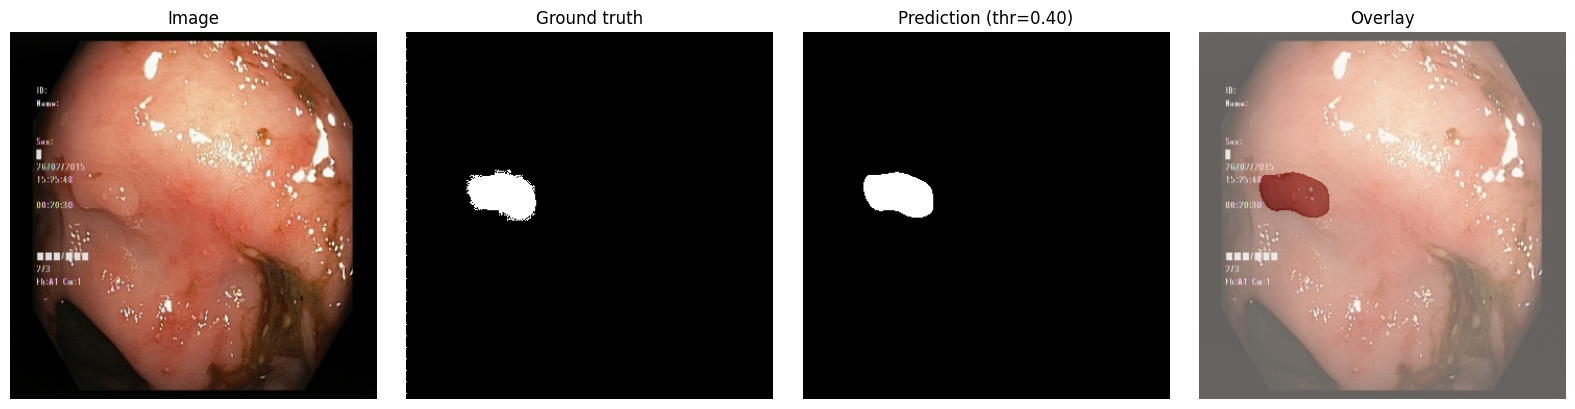

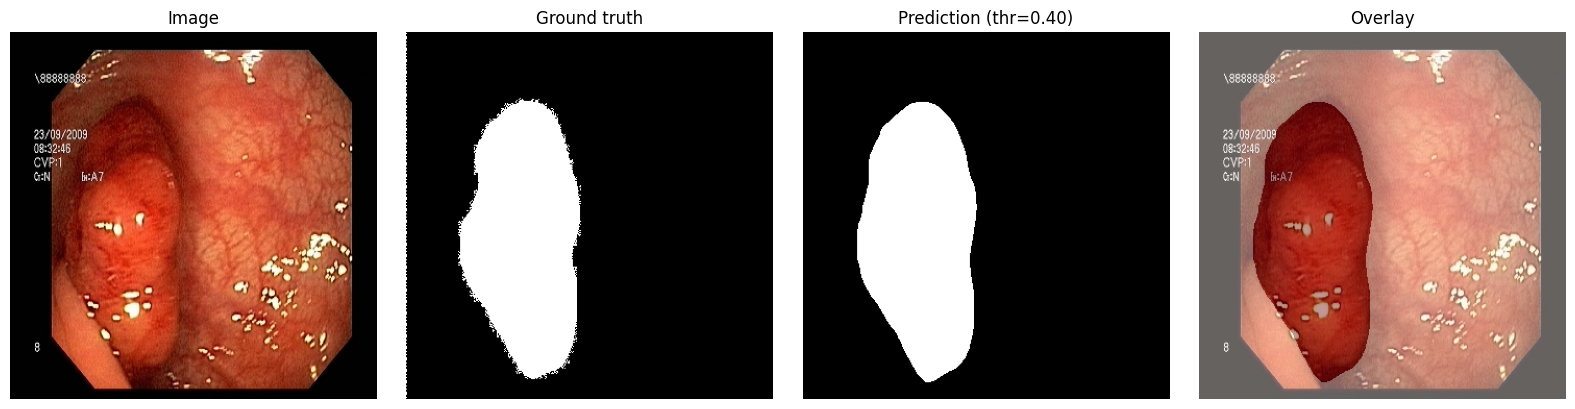

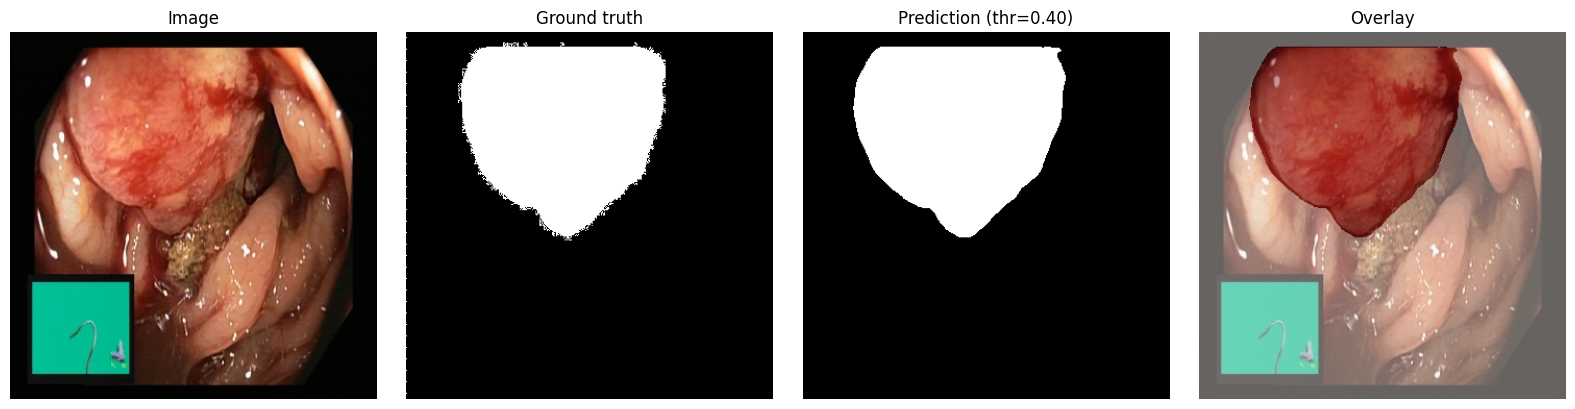

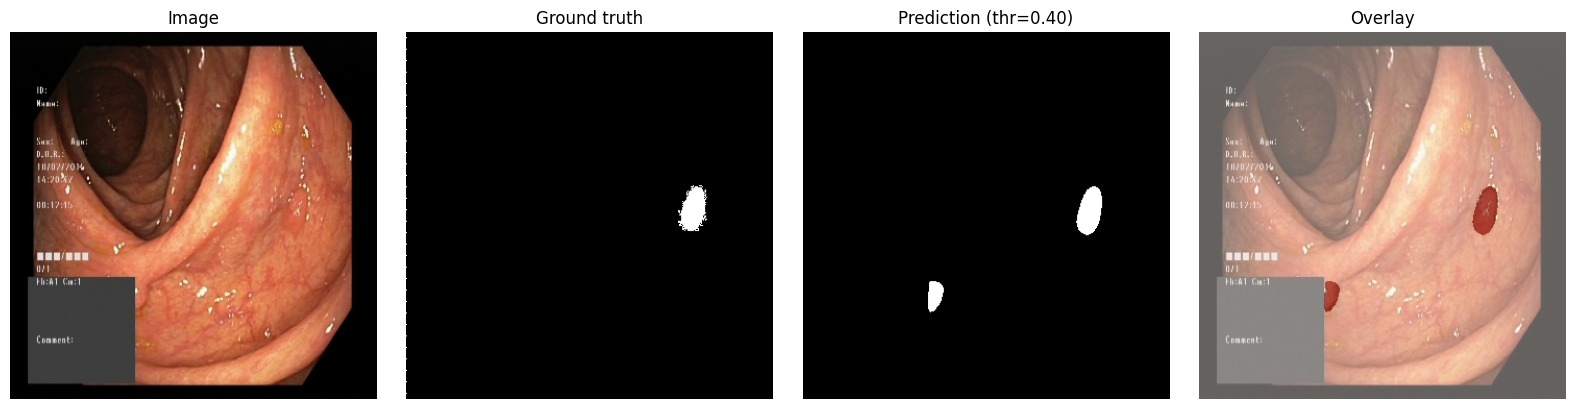

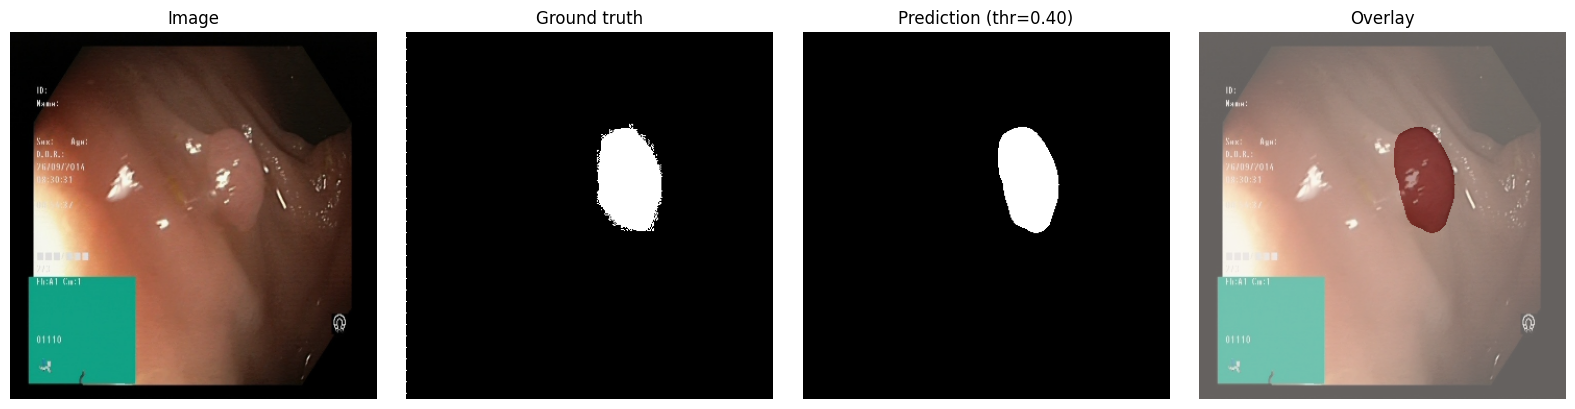

In [ ]:

# 10C. Show 5 random predictions

import random
import numpy as np
import matplotlib.pyplot as plt
import torch

thr = best_thr if "best_thr" in globals() else 0.5

model.eval()
shown = 0
target_show = 5

with torch.no_grad():
    for batch in val_loader:
        imgs = batch["image"].to(device)
        gts  = batch["mask"].to(device)

        _, pred2 = model(imgs)
        preds = torch.sigmoid(pred2)
        preds_bin = (preds > thr).float()

        imgs_np = imgs.cpu().numpy()
        gts_np = gts.cpu().numpy()
        preds_np = preds_bin.cpu().numpy()

        idxs = list(range(imgs_np.shape[0]))
        random.shuffle(idxs)

        for idx in idxs:
            img = imgs_np[idx].transpose(1, 2, 0)
            gt  = gts_np[idx, 0]
            pr  = preds_np[idx, 0]

            plt.figure(figsize=(16, 4))

            plt.subplot(1, 4, 1)
            plt.imshow(img)
            plt.title("Image")
            plt.axis("off")

            plt.subplot(1, 4, 2)
            plt.imshow(gt, cmap="gray")
            plt.title("Ground truth")
            plt.axis("off")

            plt.subplot(1, 4, 3)
            plt.imshow(pr, cmap="gray")
            plt.title(f"Prediction (thr={thr:.2f})")
            plt.axis("off")

            plt.subplot(1, 4, 4)
            plt.imshow(img)
            plt.imshow(pr, cmap="Reds", alpha=0.4)
            plt.title("Overlay")
            plt.axis("off")

            plt.tight_layout()
            plt.show()

            shown += 1
            if shown >= target_show:
                break

        if shown >= target_show:
            break


In [ ]:

# 11. Zip results

import os
import zipfile

zip_name = "polyp_pvt_real_like_results.zip"

files_to_pack = [
    "polyp_pvt_real_like_best.pt",
    "polyp_pvt_real_like_last.pt",
    "metrics.csv",
    "training_history.json",
    "best_threshold.json",
]

with zipfile.ZipFile(zip_name, "w") as z:
    for fname in files_to_pack:
        if os.path.exists(fname):
            z.write(fname)

print("ZIP ready:", zip_name)


ZIP ready: polyp_pvt_real_like_results.zip


In [ ]:

# 12. Download

from google.colab import files

files.download("polyp_pvt_real_like_results.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>